# 05 · RGB versus thirteen bands under the same spatial split

Compare fixed random forests using chip-level spectral summaries. Keep partitions, estimator settings and evaluation protocol constant, then inspect validation-set permutation importance without claiming causality.

[Notebook index](README.md) · [Companion article](../docs/articles/multispectral-experiments.md) · [Data sources and licences](../docs/DATA_SOURCES.md)

Run every cell from top to bottom in the locked Python 3.12 environment. The first run downloads the required public data pack and checks its SHA-256. Generated artifacts remain in the ignored `outputs/` directory.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

from geoai_portfolio.io import ensure_data

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 11,
        "font.size": 10,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

In [2]:
from sklearn.inspection import permutation_importance

from geoai_portfolio.experiments import EuroSAT, fit_forest, group_bootstrap, report, scores

data = ensure_data("eurosat")
dataset = EuroSAT.load(data)
train, val, test = [dataset.mask(split) for split in ["train", "val", "test"]]
truth = dataset.samples.loc[test, "label"].to_numpy()
display(pd.crosstab(dataset.samples["class"], dataset.samples.split))

split,test,train,val
class,,,
AnnualCrop,50,200,50
Forest,50,200,50
HerbaceousVegetation,50,200,50
Highway,50,200,50
Industrial,50,200,50
Pasture,50,200,50
PermanentCrop,50,200,50
Residential,50,200,50
River,50,200,50


## Control the comparison

Each selected band contributes mean, standard deviation, and the 10th, 50th and 90th
percentiles across a chip. Both models use 160 trees, minimum leaf size 2 and seed 42.
StandardScaler is included to make fitted preprocessing auditable, although a forest
does not require feature standardization. Only training rows reach `fit`.
No WorldCover labels are mixed into this supervised experiment.

,columns,accuracy,macro_f1
features,,,
RGB,15,0.5411,0.5364
13 bands,65,0.6593,0.6481


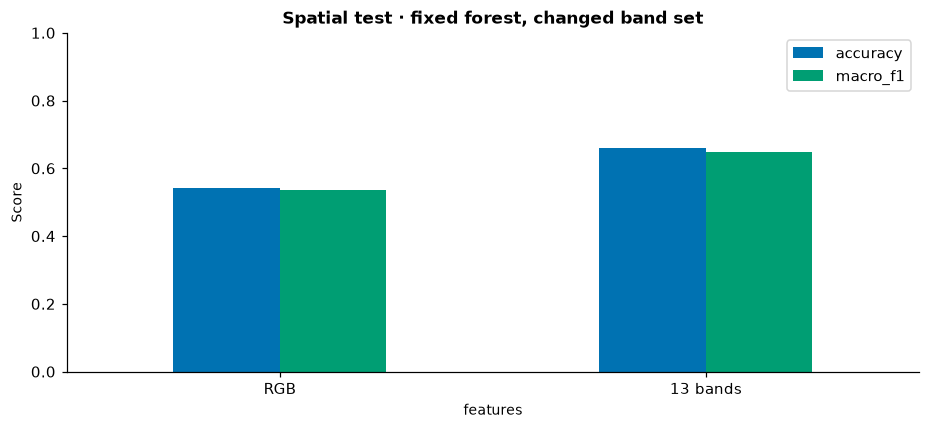

In [3]:
rgb_features = dataset.features(["B04", "B03", "B02"])
ms_features = dataset.features(dataset.bands)
models, comparisons = {}, []
for name, features in [("RGB", rgb_features), ("13 bands", ms_features)]:
    model = fit_forest(dataset, features)
    models[name] = model
    predicted = model.predict(features.loc[test])
    comparisons.append({"features": name, "columns": features.shape[1], **scores(truth, predicted)})
comparison = pd.DataFrame(comparisons).set_index("features")
display(comparison)
comparison[["accuracy", "macro_f1"]].plot.bar(color=["#0072B2", "#009E73"], rot=0, ylim=(0, 1))
plt.title("Spatial test · fixed forest, changed band set")
plt.ylabel("Score")
plt.show()

In [4]:
# Perturb every held-out feature and refit only on the unchanged training rows.
altered = ms_features.copy()
altered.loc[~train] += 1000
check_model = fit_forest(dataset, altered)
np.testing.assert_array_equal(models["13 bands"][0].mean_, check_model[0].mean_)
np.testing.assert_array_equal(
    models["13 bands"].predict(ms_features.loc[test]), check_model.predict(ms_features.loc[test])
)
print("Held-out perturbations did not change fitted statistics or predictions.")

Held-out perturbations did not change fitted statistics or predictions.


## Inspect which features the fitted model uses

Permute validation columns, not test columns, and measure macro-F1 loss. Five repeats
describe permutation variability. Correlated bands can substitute for one another,
so low marginal importance is not proof that a band contains no useful information.
This descriptive inspection does not trigger retraining or test-set model selection.

,feature,f1_drop,repeat_std
14,B02_std,0.0077,0.0078
21,B09_std,0.0064,0.0023
22,B10_std,0.0063,0.0025
7,B08_mean,0.0058,0.0032
33,B08_p10,0.0054,0.0046
8,B09_mean,0.0053,0.0013
43,B05_p50,0.0052,0.0012
48,B10_p50,0.0048,0.0012
39,B01_p50,0.0045,0.0024
18,B06_std,0.0044,0.0053


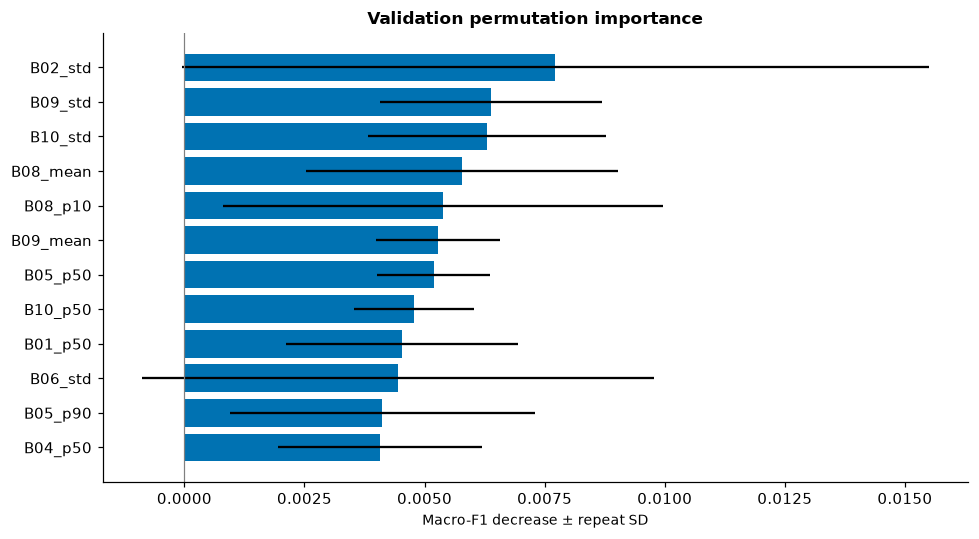

In [5]:
importance = permutation_importance(
    models["13 bands"],
    ms_features.loc[val],
    dataset.samples.loc[val, "label"],
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=1,
)
ranking = pd.DataFrame(
    {
        "feature": ms_features.columns,
        "f1_drop": importance.importances_mean,
        "repeat_std": importance.importances_std,
    }
).sort_values("f1_drop", ascending=False)
display(ranking.head(12))
top = ranking.head(12).sort_values("f1_drop")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.feature, top.f1_drop, xerr=top.repeat_std, color="#0072B2")
ax.axvline(0, color="gray", linewidth=0.8)
ax.set(title="Validation permutation importance", xlabel="Macro-F1 decrease ± repeat SD")
plt.tight_layout()
plt.show()

In [6]:
predicted = models["13 bands"].predict(ms_features.loc[test])
display(report(dataset, predicted))
display(group_bootstrap(truth, predicted, dataset.samples.loc[test, "spatial_group"]))

,precision,recall,f1-score,support
AnnualCrop,0.3333,0.1400,0.1972,50.0000
Forest,0.9231,0.9600,0.9412,50.0000
HerbaceousVegetation,0.4462,0.5800,0.5043,50.0000
Highway,0.4697,0.6200,0.5345,50.0000
Industrial,0.7500,0.7800,0.7647,50.0000
Pasture,0.7826,0.3600,0.4932,50.0000
PermanentCrop,0.4658,0.6800,0.5528,50.0000
Residential,0.6250,0.6000,0.6122,50.0000
River,0.8846,0.9200,0.9020,50.0000
SeaLake,1.0000,0.9592,0.9792,49.0000


,2.5%,median,97.5%
accuracy,0.6009,0.6617,0.7157
macro_f1,0.5761,0.6377,0.6905


## Limits and reproducibility

This class-balanced subset changes the class frequencies relative to a real map.
Accuracy therefore does not estimate area-weighted deployment accuracy. Longitude-based
regions and a 2 km footprint exclusion improve the split, but acquisition dates and
complete scene IDs are unavailable in the original chip metadata. That limits stronger
claims about temporal independence. No result here reproduces a private benchmark.

[scikit-learn permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html)
discusses the dependence of importance on the fitted model and correlated inputs.